<a href="https://colab.research.google.com/github/Mangesh0309/BE-SPPU/blob/main/Assignment2DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MULTICLASS CLASSIFICATION (OCR LETTER RECOGNITION)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
data = pd.read_csv(url, header=None)

In [3]:
data.shape

(20000, 17)

In [4]:
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [5]:
# Split Features and Labels
X = data.drop(0, axis=1)
y = data[0]

In [6]:
# Encode Labels
le = LabelEncoder()
y = le.fit_transform(y)

In [7]:
# Normalize Features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [8]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(16,)),
    Dense(64, activation='relu'),
    Dense(26, activation='softmax')
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [11]:
# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)


Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5682 - loss: 1.5923 - val_accuracy: 0.7306 - val_loss: 0.9469
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7831 - loss: 0.7509 - val_accuracy: 0.8044 - val_loss: 0.6674
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8356 - loss: 0.5616 - val_accuracy: 0.8425 - val_loss: 0.5327
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8658 - loss: 0.4558 - val_accuracy: 0.8591 - val_loss: 0.4594
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8844 - loss: 0.3829 - val_accuracy: 0.8838 - val_loss: 0.3909
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9005 - loss: 0.3305 - val_accuracy: 0.8972 - val_loss: 0.3421
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9119 - loss: 0.2879 - val_accuracy: 0.9016 - val_loss: 0.3132
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9217 - loss: 0.2533 - val_accuracy: 0.

In [12]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("accuracy:", acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9457 - loss: 0.1613
accuracy: 0.9457499980926514


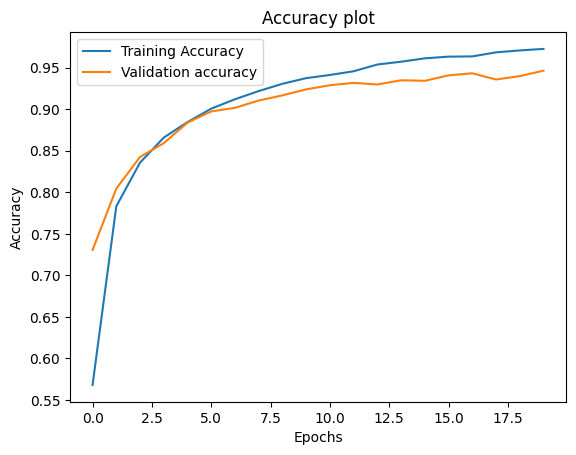

In [13]:
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy plot')
plt.legend()
plt.show()

# 2. BINARY CLASSIFICATION (IMDB SENTIMENT ANALYSIS)

In [14]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

In [15]:
# Load Dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# Pad Sequences
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test  = pad_sequences(X_test, maxlen=max_len)


In [17]:
# Build Model
model = Sequential([
    Embedding(vocab_size, 32, input_length = max_len),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [19]:
# Compile model
model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [23]:
# Train
history = model.fit(
    X_train, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=1
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 8.1323e-05 - val_accuracy: 0.8474 - val_loss: 0.9910
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 4.4433e-05 - val_accuracy: 0.8480 - val_loss: 1.0204
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 2.8933e-05 - val_accuracy: 0.8484 - val_loss: 1.0440
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 1.9495e-05 - val_accuracy: 0.8478 - val_loss: 1.0682
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 1.3259e-05 - val_accuracy: 0.8482 - val_loss: 1.0935


In [24]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)
print("Loss:", loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8424 - loss: 1.0730
Accuracy: 0.8424400091171265
Loss: 1.0729961395263672


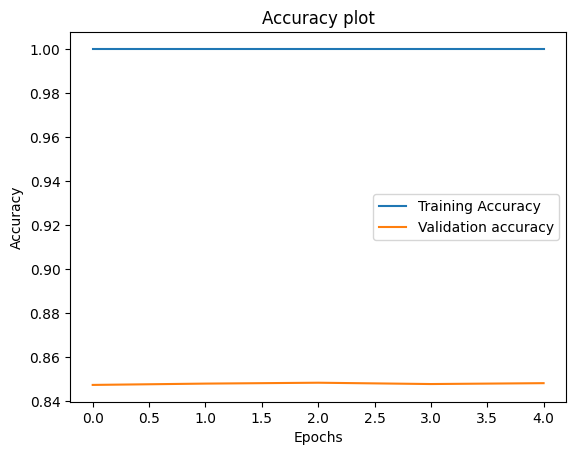

In [25]:
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy plot')
plt.legend()
plt.show()